In [20]:
# Deactivate distracting warnings
import warnings
warnings.filterwarnings("ignore")

In [21]:
from utils.data_processing import *
from utils.visualization import load_data, plot_event_count, plot_kde, plot_goal_positions
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

In [3]:
path = "./idsse-data/DFL-MAT-J03WOH/"
file_name_pos = "DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WOH.xml"
file_name_infos = "DFL_02_01_matchinformation_DFL-COM-000002_DFL-MAT-J03WOH.xml"
file_name_events = "DFL_03_02_events_raw_DFL-COM-000002_DFL-MAT-J03WOH.xml"
xy_objects, events, pitch, possession, ballstatus, teamsheets = load_data(path, file_name_pos, file_name_infos, file_name_events)

len(xy_objects["firstHalf"]["Home"][0])=40

In [ ]:
teamsheets['Home']['position']

pandas.core.series.Series

In [7]:

# 1. xy_objects 안의 xy 배열만 쏙 빼냅니다.
Home_first = xy_objects["firstHalf"]["Home"].xy 
Away_first = xy_objects["firstHalf"]["Away"].xy 
# 2. np.isnan()으로 nan인 것을 찾고, '~' 기호로 반전(nan이 아닌 것)시킨 뒤 열(axis=0) 기준으로 더합니다.
non_nan_counts = np.sum(~np.isnan(Home_first), axis=0)
non_nan_counts_2 = np.sum(~np.isnan(Away_first), axis=0)
print("각 컬럼별 정상(non-NaN) 데이터 개수:")
print(non_nan_counts)
print(non_nan_counts_2)

각 컬럼별 정상(non-NaN) 데이터 개수:
[    0     0     0     0 69424 69424 69424 69424 69424 69424 69424 69424
 69424 69424 69424 69424 69424 69424 69424 69424     0     0 69424 69424
 69424 69424     0     0     0     0 69424 69424     0     0     0     0
     0     0     0     0]
[69424 69424 69424 69424 69424 69424 69424 69424     0     0 69424 69424
 69424 69424     0     0 69424 69424     0     0     0     0 69424 69424
 69424 69424 69424 69424     0     0     0     0 69424 69424     0     0
     0     0]


In [17]:
Home_first_df = pd.DataFrame(Home_first)
Home_first_df

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,NaN,NaN,NaN,NaN,-0.59,8.72,12.53,20.32,16.45,6.50,...,1.85,-13.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,-0.71,8.63,12.55,20.34,16.47,6.56,...,1.79,-13.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,-0.83,8.54,12.59,20.35,16.51,6.60,...,1.71,-13.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,-0.97,8.44,12.62,20.38,16.54,6.65,...,1.64,-13.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,-1.11,8.34,12.65,20.41,16.57,6.70,...,1.55,-13.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69419,NaN,NaN,NaN,NaN,-16.14,-19.76,4.26,-7.06,6.90,-15.88,...,1.40,-31.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69420,NaN,NaN,NaN,NaN,-16.11,-19.80,4.17,-7.04,6.89,-15.93,...,1.41,-31.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69421,NaN,NaN,NaN,NaN,-16.07,-19.85,4.08,-7.01,6.89,-15.98,...,1.43,-31.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69422,NaN,NaN,NaN,NaN,-16.04,-19.91,4.00,-6.99,6.88,-16.04,...,1.44,-32.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# (69424, 40) 형태의 2차원 배열을 (69424, 20, 2) 형태의 3차원 배열로 재배열
# 차원 의미: [프레임 인덱스, ID, 0(x) 또는 1(y)]
reshaped_xy = xy_objects["firstHalf"]["Home"].xy.reshape(-1, 20, 2)

# 예: 100번째 프레임에서 ID 5번의 x좌표, y좌표 가져오기
frame_100_id_5_coords = reshaped_xy[100, 5, :] 
print("프레임 100, ID 5의 [x, y] 좌표:", frame_100_id_5_coords)
# lb lcb rcb rb
target_def_home_ids = [3, 4, 8, 12]

selected_xy = reshaped_xy[:, target_def_home_ids, :]

print("추출된 배열의 크기:", selected_xy.shape)
# (69424, 4, 2)
# 1. 점유권 배열만 꺼내기 (크기: 69424,)
poss_array = possession['firstHalf'].code

# 2. 차원 맞추기 
# (69424,) -> (69424, 1, 1)로 3차원으로 만든 뒤, 4명의 선수 모두에게 동일하게 적용되도록 복사(Broadcast)합니다.
poss_expanded = poss_array.reshape(-1, 1, 1)
poss_broadcast = np.broadcast_to(poss_expanded, (69424, 4, 1))

# 3. selected_xy(69424, 4, 2)와 poss_broadcast(69424, 4, 1)를 마지막 축(axis=2)을 기준으로 결합!
xy_with_possession_3d = np.concatenate([selected_xy, poss_broadcast], axis=2)

print("결합된 3차원 배열 크기:", xy_with_possession_3d.shape)
# 출력 예상: (69424, 4, 3) 
# -> 이제 xy_with_possession_3d[0, 0, :] 을 찍어보면 [x좌표
mask = (possession['firstHalf'].code == 2)
filtered_3d = xy_with_possession_3d[mask]
print("필터링 후 3차원 배열 크기:", filtered_3d.shape)
filtered_3d

프레임 100, ID 5의 [x, y] 좌표: [ 3.59 18.04]
추출된 배열의 크기: (69424, 4, 2)
결합된 3차원 배열 크기: (69424, 4, 3)
필터링 후 3차원 배열 크기: (32816, 4, 3)


array([[[ 12.53,  20.32,   2.  ],
        [ 16.45,   6.5 ,   2.  ],
        [ 17.32,  -5.08,   2.  ],
        [ 13.81, -14.5 ,   2.  ]],

       [[ 12.55,  20.34,   2.  ],
        [ 16.47,   6.56,   2.  ],
        [ 17.29,  -5.07,   2.  ],
        [ 13.82, -14.52,   2.  ]],

       [[ 12.59,  20.35,   2.  ],
        [ 16.51,   6.6 ,   2.  ],
        [ 17.27,  -5.06,   2.  ],
        [ 13.84, -14.54,   2.  ]],

       ...,

       [[-13.97,  -1.05,   2.  ],
        [-42.71,  -2.86,   2.  ],
        [-40.46,   2.24,   2.  ],
        [-26.34, -14.52,   2.  ]],

       [[-13.93,  -1.09,   2.  ],
        [-42.65,  -2.83,   2.  ],
        [-40.35,   2.24,   2.  ],
        [-26.35, -14.43,   2.  ]],

       [[-13.89,  -1.14,   2.  ],
        [-42.58,  -2.81,   2.  ],
        [-40.23,   2.26,   2.  ],
        [-26.37, -14.35,   2.  ]]], shape=(32816, 4, 3))

In [22]:
# 1. 4명 선수의 x좌표와 y좌표만 각각 따로 분리합니다.
# x_coords, y_coords의 크기는 각각 (32816, 4)가 됩니다.
x_coords = filtered_3d[:, :, 0]
y_coords = filtered_3d[:, :, 1]

# 2. 너비 (Width) 계산: 프레임별 y좌표의 최댓값(가장 우측) - 최솟값(가장 좌측)
line_width = np.max(y_coords, axis=1) - np.min(y_coords, axis=1)

# 3. 깊이 (Depth) 계산: 프레임별 x좌표의 최댓값(가장 앞선 선수) - 최솟값(가장 처진 선수)
# (이 값이 작을수록 '일자 수비'에 가깝습니다)
line_depth = np.max(x_coords, axis=1) - np.min(x_coords, axis=1)

# 4. 라인 높이 (Line Height) 계산: 4명 선수의 x좌표 평균값
line_height = np.mean(x_coords, axis=1)

# 5. Clustering(군집화)을 위한 최종 데이터셋으로 합치기
# column_stack을 사용해 1차원 배열들을 세로로 나란히 세워 2차원 표 형태로 만듭니다.
# 1. Y좌표(가로)를 기준으로 선수들을 왼쪽부터 오른쪽으로 정렬합니다.
# sort_indices는 각 프레임별로 Y값이 작은(왼쪽) 순서대로 0~3의 인덱스를 반환합니다.
sort_indices = np.argsort(y_coords, axis=1)

# 고급 인덱싱을 통해 정렬된 X, Y 좌표를 만듭니다. (크기: 32816, 4)
# 이제 인덱스 0: LB, 1: LCB, 2: RCB, 3: RB 가 확실하게 보장됩니다.
frames = np.arange(x_coords.shape[0])[:, None]
sorted_x = x_coords[frames, sort_indices]
sorted_y = y_coords[frames, sort_indices]

# ---------------------------------------------------------
# [Feature 4, 5, 6]: 상대적 깊이 차이 (단차 계산)
# ---------------------------------------------------------
# 왼쪽 풀백 전진 정도 (Left Up)
left_wing_diff = sorted_x[:, 0] - sorted_x[:, 1]  
# 오른쪽 풀백 전진 정도 (Right Up)
right_wing_diff = sorted_x[:, 3] - sorted_x[:, 2] 
# 센터백 간의 깊이 차이
center_diff = sorted_x[:, 1] - sorted_x[:, 2]     

# ---------------------------------------------------------
# [Feature 7, 8]: 양쪽 끝 선분의 각도 (기울기)
# ---------------------------------------------------------
# np.arctan2(y의 변화량, x의 변화량)을 사용하여 각도(Radian)를 구하고 Degree로 변환합니다.
# 왼쪽 센터백(LCB)에서 왼쪽 풀백(LB)으로 향하는 선의 각도
angle_left = np.degrees(np.arctan2(sorted_x[:, 0] - sorted_x[:, 1], 
                                   sorted_y[:, 0] - sorted_y[:, 1]))

# 오른쪽 센터백(RCB)에서 오른쪽 풀백(RB)으로 향하는 선의 각도
angle_right = np.degrees(np.arctan2(sorted_x[:, 3] - sorted_x[:, 2], 
                                    sorted_y[:, 3] - sorted_y[:, 2]))

# ---------------------------------------------------------
# 기존 데이터(너비, 깊이, 라인높이)와 새로운 형태 지표들을 모두 합치기!
# ---------------------------------------------------------
advanced_features = np.column_stack((
    line_width, line_depth, line_height,  # 기존 3개 지표
    left_wing_diff, right_wing_diff, center_diff, # 새로운 단차 지표 3개
    angle_left, angle_right # 새로운 각도 지표 2개
))

print("--- 고급 형태(Shape) Feature 생성 완료 ---")
print("새로운 배열 크기:", advanced_features.shape) # 예상: (32816, 8)

--- 고급 형태(Shape) Feature 생성 완료 ---
새로운 배열 크기: (32816, 8)


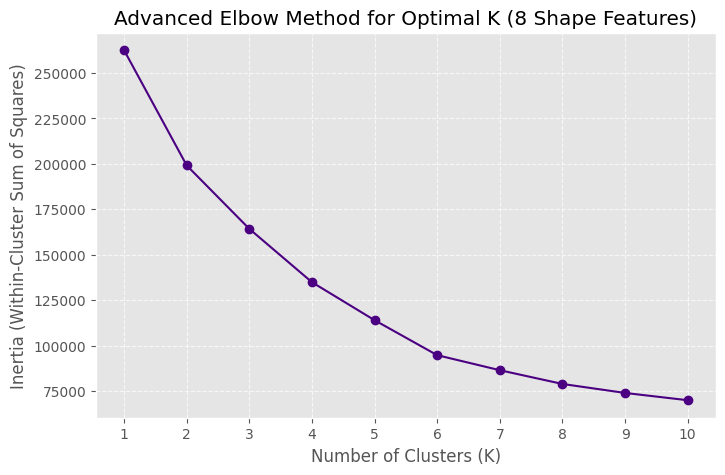

In [23]:

# 1. 8차원 고급 형태 데이터 스케일링 (필수: 단위가 다른 지표들을 정규화)
scaler_adv = StandardScaler()
scaled_adv_features = scaler_adv.fit_transform(advanced_features)

# 2. 1개부터 10개까지 군집 개수(K)를 늘려가며 오차(Inertia) 계산
inertia_adv = []
K_range_adv = range(1, 11)

for k in K_range_adv:
    kmeans_adv = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_adv.fit(scaled_adv_features)
    inertia_adv.append(kmeans_adv.inertia_)

# 3. 새로운 엘보우 그래프 그리기
plt.figure(figsize=(8, 5))
plt.plot(K_range_adv, inertia_adv, marker='o', linestyle='-', color='indigo')
plt.title('Advanced Elbow Method for Optimal K (8 Shape Features)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range_adv)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [24]:
optimal_k_adv = 6
kmeans_adv = KMeans(n_clusters=optimal_k_adv, random_state=42, n_init=10)

cluster_labels_adv = kmeans_adv.fit_predict(scaled_adv_features)

feature_names = [
    'Width(너비)', 'Depth(깊이)', 'Height(라인높이)', 
    'Left_Down(좌단차)', 'Right_Down(우단차)', 'Center_Diff(중앙단차)', 
    'Angle_L(좌측각도)', 'Angle_R(우측각도)'
]

df_adv_clusters = pd.DataFrame(advanced_features, columns=feature_names)
df_adv_clusters['Cluster'] = cluster_labels_adv

# compute mean by each clusters
cluster_summary_adv = df_adv_clusters.groupby('Cluster').mean().round(2)


cluster_summary_adv['Frame_Count'] = df_adv_clusters['Cluster'].value_counts()

print("--- 6가지 세부 수비 형태별 평균 지표 ---")
print(cluster_summary_adv)

--- 6가지 세부 수비 형태별 평균 지표 ---
         Width(너비)  Depth(깊이)  Height(라인높이)  Left_Down(좌단차)  Right_Down(우단차)  \
Cluster                                                                        
0             9.55       5.22         42.74           -2.77             0.50   
1            28.89       5.82         16.64           -3.23            -3.79   
2            37.79      18.72         -2.24          -13.39           -13.16   
3            25.45       4.53         16.47            1.60            -3.26   
4            20.18      21.99         -7.11            6.14            20.64   
5            29.65      28.76        -24.09           13.91           -25.57   

         Center_Diff(중앙단차)  Angle_L(좌측각도)  Angle_R(우측각도)  Frame_Count  
Cluster                                                                
0                     0.41        -103.20           6.49         4968  
1                    -0.49        -160.99         -22.35        14306  
2                     0.72        -135.57  

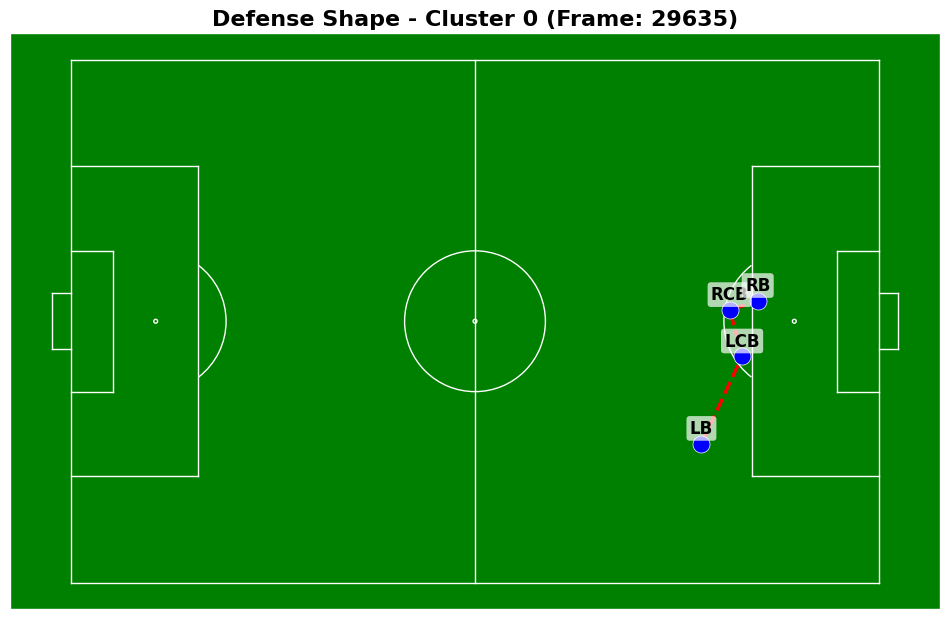

5.821738431427374


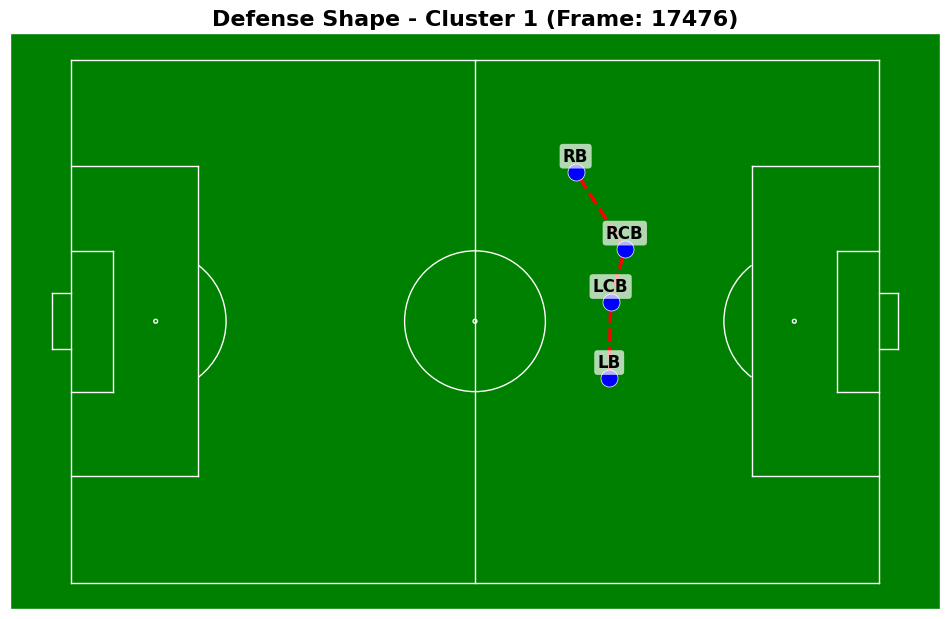

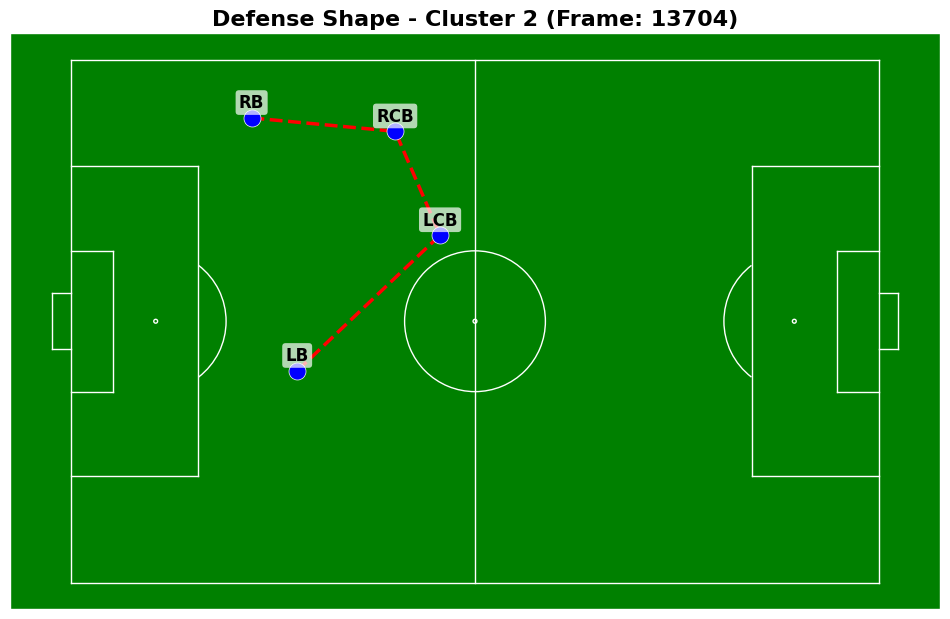

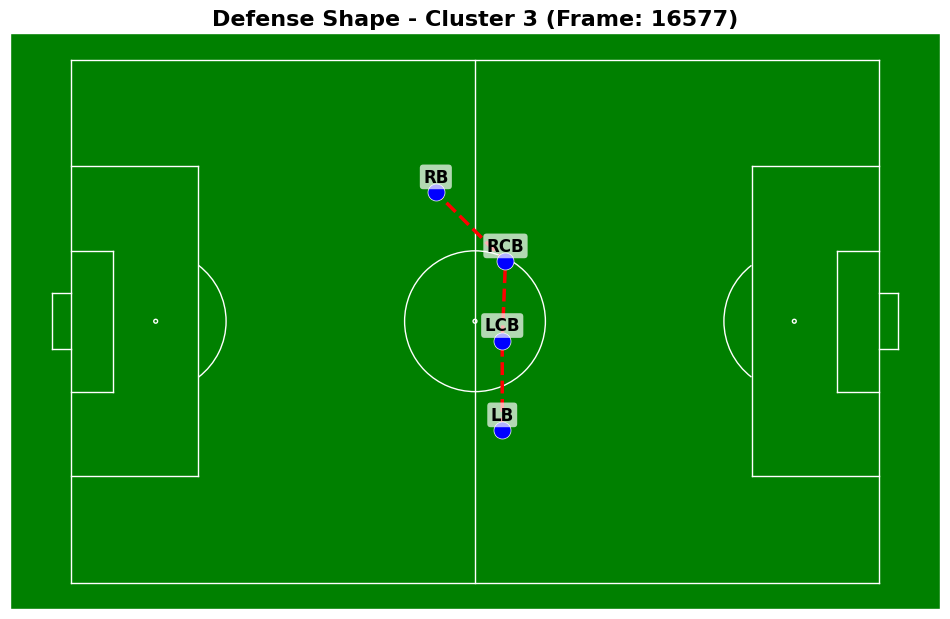

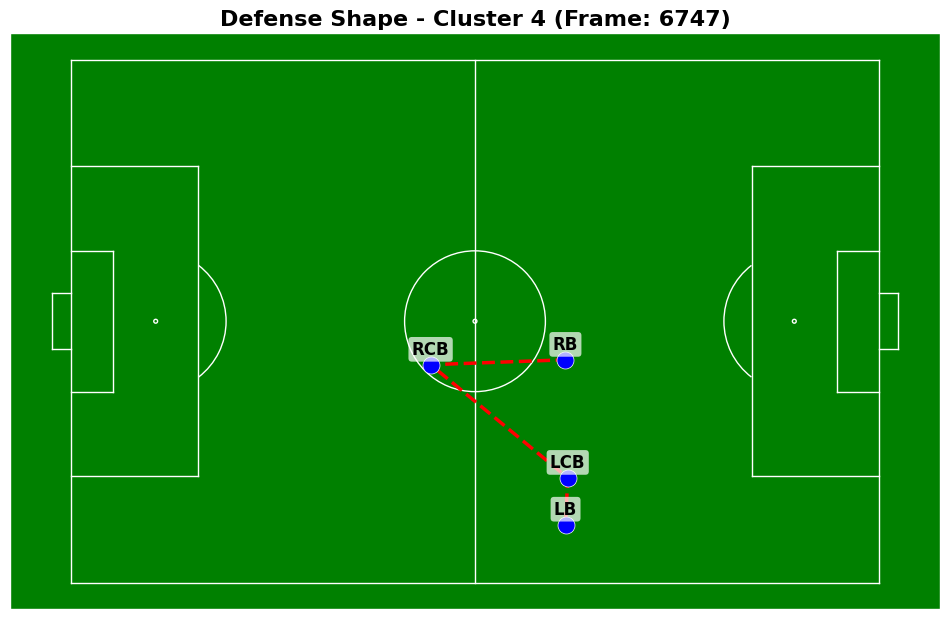

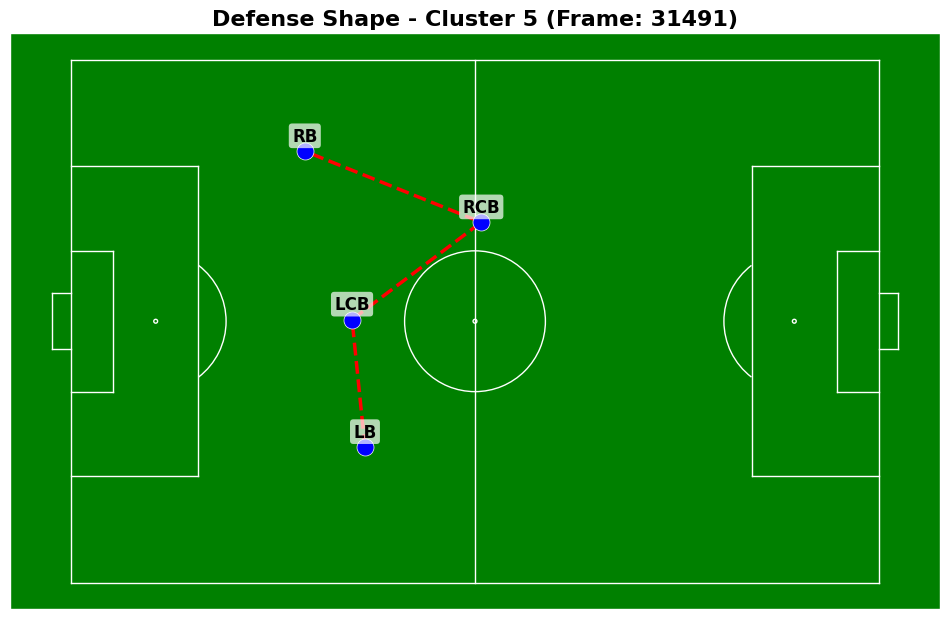

In [26]:
def plot_defense_shape(cluster_num, sorted_x, sorted_y, labels, pitch):
    """
    특정 군집(Cluster)의 수비 형태를 하나 골라 경기장에 시각화하는 함수
    """
    cluster_indices = np.where(labels == cluster_num)[0]
    
    if len(cluster_indices) == 0:
        print(f"invalid Cluster {cluster_num}")
        return
    
    target_frame = np.random.choice(cluster_indices)
    
  
    x_coords = sorted_x[target_frame]
    y_coords = sorted_y[target_frame]
    
    x_coords_c3 = []
    y_coords_c3 = []
    if cluster_num==1:
        for f in cluster_indices:
            x_coords_c3.append(sorted_x[f])
            
        ranges = [row.max() - row.min() for row in x_coords_c3]
        avg_range = np.mean(ranges)

        print(avg_range)
        
    fig, ax = plt.subplots(figsize=(12, 8))
    pitch.plot(ax=ax) 
    
  
    ax.plot(x_coords, y_coords, color='red', linestyle='--', linewidth=2.5, zorder=1)
    
    
    ax.scatter(x_coords, y_coords, color='blue', s=150, edgecolors='white', zorder=2)
    
   
    positions = ['LB', 'LCB', 'RCB', 'RB']
    for i in range(4):

        ax.text(x_coords[i], y_coords[i] + 2, positions[i], 
                color='black', fontsize=12, ha='center', va='center', fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))
    
    plt.title(f"Defense Shape - Cluster {cluster_num} (Frame: {target_frame})", fontsize=16, fontweight='bold')
    plt.show()
    

for i in range (6):
    plot_defense_shape(i, sorted_x, sorted_y, cluster_labels_adv, pitch)


so candiate threshold is 4.5, 4.6, 4.7

In [46]:
thr = 5.8